# 01 — Data Exploration

Explore the sampled FOMC corpus: meeting counts, date coverage, section availability, and passage length distributions.

In [1]:
import sys
sys.path.insert(0, '..')  # make src/ importable from notebooks/

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
ROOT = Path('..')
PROCESSED = ROOT / 'data' / 'processed'
OUTPUTS = ROOT / 'outputs'

## 1. Sampled meetings

In [11]:
meetings = pd.read_csv(PROCESSED / 'sampled_meetings.csv', parse_dates=['date'])
print(f'Total meetings: {len(meetings)}')
meetings.groupby('period')['date'].agg(['count', 'min', 'max'])

Total meetings: 30


,count,min,max
period,,,
great_moderation,10,2000-12-19,2007-09-18
post_covid,10,2022-09-21,2025-12-10
post_crisis_zlb,10,2010-05-09,2019-09-18


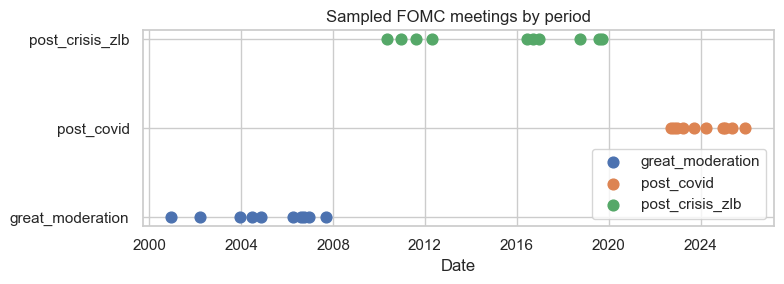

In [12]:
fig, ax = plt.subplots(figsize=(8, 3))
for period, grp in meetings.groupby('period'):
    ax.scatter(grp['date'], [period]*len(grp), s=60, label=period)
ax.set_xlabel('Date')
ax.set_title('Sampled FOMC meetings by period')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 2. Passages

In [15]:
passages = pd.read_csv(OUTPUTS / 'passages.csv')
print(f'Total passages: {len(passages)}')
passages.groupby('period')['passage_id'].count().rename('passages')

Total passages: 734


period
great_moderation    286
post_covid          210
post_crisis_zlb     238
Name: passages, dtype: int64

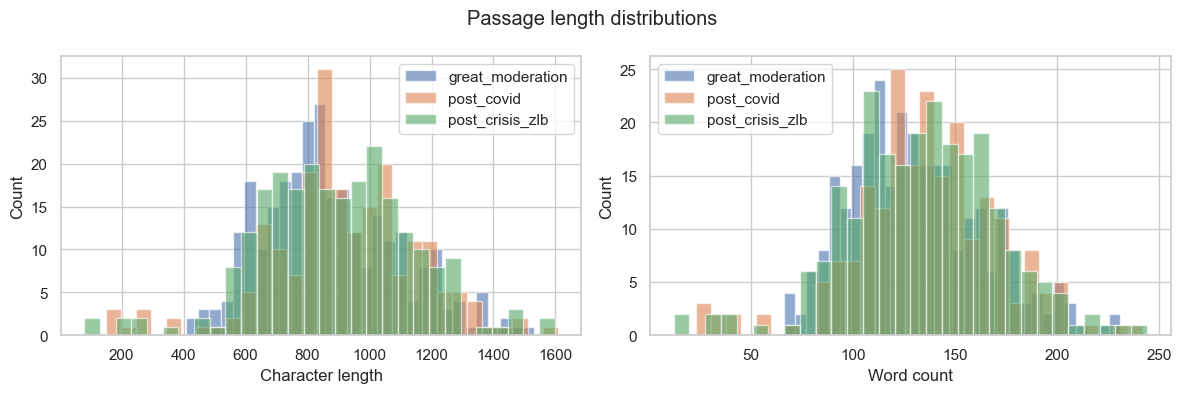

In [16]:
passages['char_len'] = passages['text'].str.len()
passages['word_count'] = passages['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ['char_len', 'word_count'], ['Character length', 'Word count']):
    for period, grp in passages.groupby('period'):
        ax.hist(grp[col], bins=30, alpha=0.6, label=period)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend()
plt.suptitle('Passage length distributions')
plt.tight_layout()
plt.show()

In [17]:
# Section coverage
passages.groupby(['period', 'section'])['passage_id'].count().rename('passages').unstack(fill_value=0)

section,Participants' Views on Current Conditions and the Economic Outlook,Staff Review of the Economic Situation,full_document
period,,,
great_moderation,0,0,286
post_covid,151,59,0
post_crisis_zlb,132,106,0


In [9]:
# get long passages 
long_passages = passages[passages['word_count'] >= 300]
long_passages.to_csv(OUTPUTS / 'long_passages.csv', index=False)